# RailCross model evaluation

## tl;dr

The current model reached **94.4% F1** and **99.6% ROC-AUC** on a held-out synthetic event split. The reopening-time model achieved **1.68 minutes MAE**.

These are **synthetic benchmark results only**. They demonstrate the pipeline and model behavior; they do not establish real-world accuracy.

## Context & Methods

RailCross predicts whether a known railway crossing is currently closed and, when closed, estimates the remaining time until reopening.

### Key Assumptions

- The simulator mirrors public Google Routes-style inputs: traffic-aware duration, static duration, and NORMAL/SLOW/TRAFFIC_JAM segment states.
- It does not reproduce or claim access to Google internal traffic data.
- Events are split chronologically by `event_id`, preventing snapshots from the same event appearing in both train and test sets.
- Ordinary road congestion is simulated as a negative class so the classifier cannot equate every traffic jam with a railway closure.

In [1]:
from pathlib import Path
import csv
import json
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATASET = ROOT / 'data' / 'synthetic' / 'crossing_observations.csv'
REPORT = ROOT / 'artifacts' / 'model_evaluation.json'
report = json.loads(REPORT.read_text())
report['dataset']

{'path': 'data/synthetic/crossing_observations.csv',
 'source': 'Google-Routes-like synthetic simulator; not Google internal data',
 'rows': 29900,
 'events': 650,
 'positive_rate': 0.2386,
 'split': 'Chronological event split: 70% train, 15% validation, 15% test'}

## Data

The generated dataset is event-based. Each row represents one 30-second observation.

In [2]:
with DATASET.open(newline='') as handle:
    rows = list(csv.DictReader(handle))

gate_labels = np.array([int(row['gate_closed']) for row in rows])
event_ids = np.array([int(row['event_id']) for row in rows])
scenario_counts = {}
for row in rows:
    scenario_counts[row['scenario_kind']] = scenario_counts.get(row['scenario_kind'], 0) + 1

{
    'rows': len(rows),
    'events': len(np.unique(event_ids)),
    'closed_state_share': round(float(gate_labels.mean()), 4),
    'scenario_rows': scenario_counts,
}

{'rows': 29900,
 'events': 650,
 'closed_state_share': 0.2386,
 'scenario_rows': {'ordinary_congestion': 6394,
  'normal_flow': 3358,
  'railway_closure': 20148}}

### Data checks

Verify label ranges, remaining-time consistency, and event coverage.

In [3]:
remaining = np.array([float(row['remaining_closed_seconds']) for row in rows])
assert set(np.unique(gate_labels)).issubset({0, 1})
assert np.all(remaining[gate_labels == 0] == 0)
assert np.all(remaining[gate_labels == 1] > 0)
assert len(np.unique(event_ids)) == report['dataset']['events']
print('All dataset consistency checks passed.')

All dataset consistency checks passed.


## Results

In [4]:
status = report['classifier']['test_metrics']
baseline = report['baseline_rule']
for metric in ['accuracy', 'precision', 'recall', 'f1', 'false_positive_rate']:
    print(f"{metric:>22}: model={status[metric]:.3f}  baseline={baseline[metric]:.3f}")
print(f"{'roc_auc':>22}: model={status['roc_auc']:.3f}")

              accuracy: model=0.974  baseline=0.810
             precision: model=0.949  baseline=0.630
                recall: model=0.939  baseline=0.447
                    f1: model=0.944  baseline=0.523
   false_positive_rate: model=0.015  baseline=0.080
               roc_auc: model=0.996


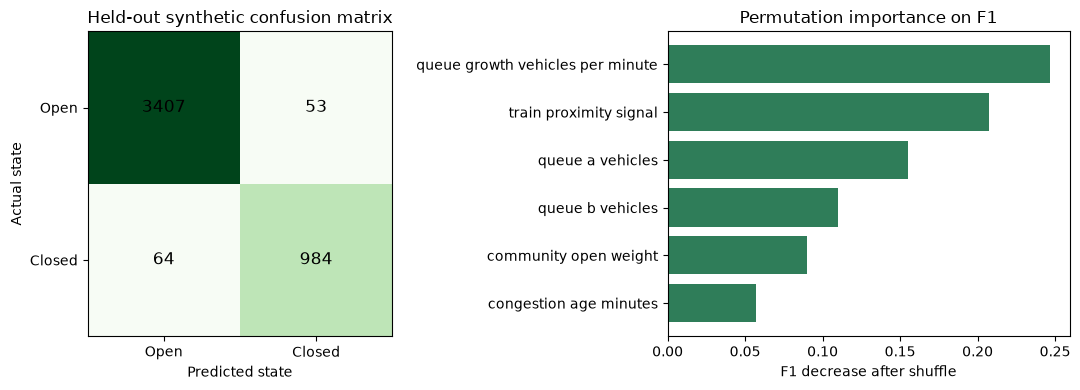

In [5]:
matrix = np.array(report['classifier']['test_metrics']['confusion_matrix'])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(matrix, cmap='Greens')
axes[0].set_title('Held-out synthetic confusion matrix')
axes[0].set_xlabel('Predicted state')
axes[0].set_ylabel('Actual state')
axes[0].set_xticks([0, 1], ['Open', 'Closed'])
axes[0].set_yticks([0, 1], ['Open', 'Closed'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, matrix[i, j], ha='center', va='center', fontsize=12)

features = report['classifier']['top_permutation_features'][:6]
names = [item[0].replace('_', ' ') for item in features][::-1]
values = [item[1] for item in features][::-1]
axes[1].barh(names, values, color='#2f7d59')
axes[1].set_title('Permutation importance on F1')
axes[1].set_xlabel('F1 decrease after shuffle')
plt.tight_layout()
plt.show()

## Takeaways

- The classifier outperformed the transparent traffic-delay rule on the held-out synthetic events.
- Reopening-time MAE was **1.68 minutes** in this simulator.
- The current evidence is suitable for demonstrating architecture and reproducibility, not claiming production accuracy.
- The next validation step is to record independent real crossing events and report synthetic and real metrics separately.

**Data source:** `data/synthetic/crossing_observations.csv`  
**Evaluation artifact:** `artifacts/model_evaluation.json`